In [45]:
  
import torch
from matplotlib import pyplot as plt
import numpy as np
device = 'cpu'
ckpt    = torch.load("ggn_lanczos.pt", map_location=device)
ggn_eigvals = ckpt["eigvals"].to(torch.float32).to(device)
ggn_max = ggn_eigvals.max()
ggn_eigvals /=ggn_eigvals.max()
ggn_eigvecs = ckpt["eigvecs"].to(torch.float32).to(device)

ckpt    = torch.load("symo_eig.pt", map_location=device)
symo_eigvals = np.array(ckpt["eigvals"].to(torch.float32).to(device))[::-1]
symo_max = symo_eigvals.max()
symo_eigvals /=symo_eigvals.max()

symo_eigvecs = ckpt["eigvecs"].to(torch.float32).to(device)

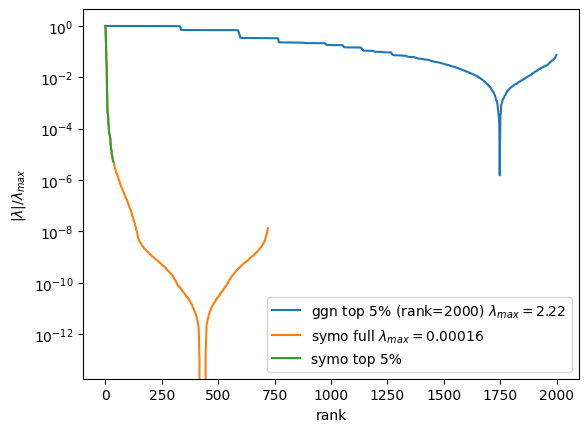

In [50]:
plt.plot(np.abs(ggn_eigvals),label=r'ggn top 5% (rank=2000) $\lambda_{max}=$'+str(np.around(float(ggn_max),2)))
plt.plot(np.abs(symo_eigvals),label =r'symo full $\lambda_{max}=$'+str(np.around(symo_max,5)))
plt.plot(np.abs(symo_eigvals[:int(len(symo_eigvals)*0.05)]),label= 'symo top 5%')
plt.yscale('log')
plt.ylabel(r'$|\lambda|/\lambda_{max}$')
plt.xlabel('rank')
plt.legend()
plt.show()

In [25]:
ggn_eigvals

tensor([ 1.0000,  0.9997,  0.9991,  ..., -0.0702, -0.0727, -0.0742])